# Deep Learning Fundamentals - Mini-Project

## MNIST Digits - CNN Evaluation

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import torch
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

from mnist_datamodule import MNISTDataModule
from mnist_cnn_classifier import MNISTCNN

In [3]:
CKPT_PATH = "checkpoints/mnist_cnn_best.ckpt"
CLASS_NAMES = [str(i) for i in range(10)]

In [4]:
model = MNISTCNN.load_from_checkpoint(CKPT_PATH)
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

MNISTCNN(
  (act): GELU(approximate='none')
  (encoder): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): GELU(approximate='none')
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): GELU(approximate='none')
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=128, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
  (criterion): CrossEntropyLoss()
  (acc_tr): MulticlassAccuracy()
  (acc_va): MulticlassAccuracy()
  (acc_te): Multic

### Checkpoint load & CNN summary
- Loaded the best CNN checkpoint and set the module to `eval()` on the available device (**GPU if present, else CPU**).
- The printed summary confirms a **3-block conv encoder** with **GELU** activations and **MaxPool(2)** after each conv:
  - `Conv2d(1→128, k=3, p=1) → GELU → MaxPool(2)`
  - `Conv2d(128→256, k=3, p=1) → GELU → MaxPool(2)`
  - `Conv2d(256→256, k=3, p=1) → GELU → MaxPool(2)`
- **Head:** `Flatten → Linear(2304→128) → GELU → Linear(128→10)` producing logits for the 10 digit classes.
- **Loss/metrics:** `CrossEntropyLoss`; accuracy tracked for train/val/test.
- No BatchNorm in this CNN; regularization comes from pooling and the small fully connected head.


In [5]:
dm = MNISTDataModule(batch_size=256, augment=False)
dm.prepare_data(); dm.setup()

In [6]:
device = next(model.parameters()).device
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in dm.test_dataloader():
        x = x.to(device); y = y.to(device)
        logits = model(x)
        y_true.append(y.cpu().numpy())
        y_pred.append(logits.argmax(dim=1).cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

### Test-set predictions
- Build the `MNISTDataModule` with `batch_size=256` and no augmentation; call `prepare_data()` and `setup()`.
- Move batches to the model’s device and run in `torch.no_grad()` to collect `y_true` and argmax logits as `y_pred`.
- Outputs (`y_true`, `y_pred`) are concatenated numpy arrays ready for metrics, confusion matrices and per-class reports.


Using metrics: logs/mnist_cnn_final/version_1/metrics.csv


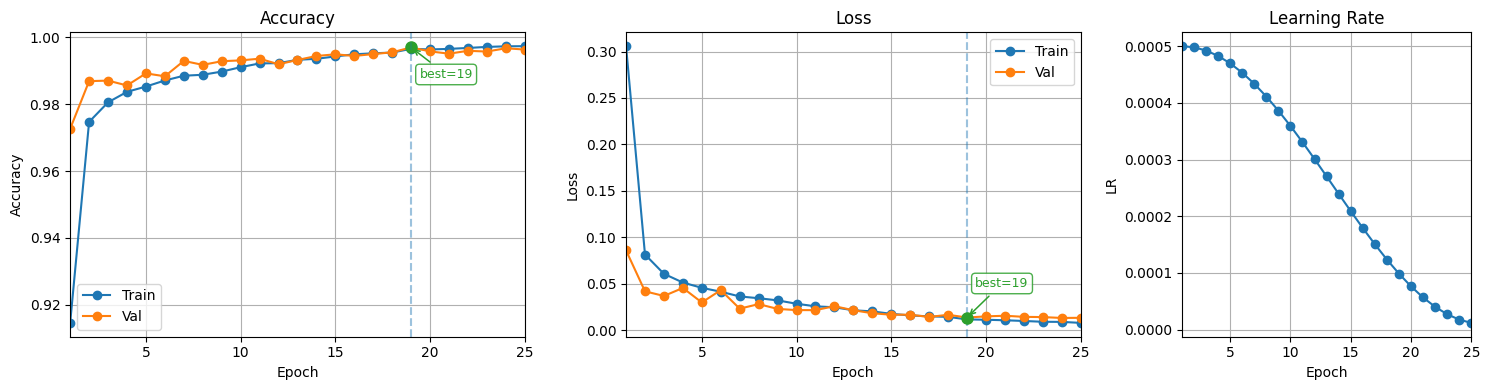

In [7]:
LOG_ROOT = "logs/mnist_cnn_final"

version_dirs = []
for root, dirs, files in os.walk(LOG_ROOT):
    version_dirs += [os.path.join(root, d) for d in dirs if d.startswith("version_")]
assert version_dirs, f"No lightning CSV logs found under '{LOG_ROOT}/'."
version_path = sorted(version_dirs, key=lambda p: int(os.path.basename(p).split("_")[-1]))[-1]
metrics_csv = os.path.join(version_path, "metrics.csv")
print("Using metrics:", metrics_csv)

df = pd.read_csv(metrics_csv)

def last_per_epoch(df_in: pd.DataFrame, col: str) -> pd.DataFrame:
    if col not in df_in.columns:
        return pd.DataFrame(columns=["epoch", col])
    tmp = df_in.loc[~df_in[col].isna(), ["epoch", col]]
    return tmp.groupby("epoch", as_index=False).last()

# Resolve possible column name variants
val_acc_col  = "val_acc"    if "val_acc"    in df.columns else ("val_acc_epoch"    if "val_acc_epoch"    in df.columns else None)
trn_acc_col  = "train_acc"  if "train_acc"  in df.columns else ("train_acc_epoch"  if "train_acc_epoch"  in df.columns else None)
val_loss_col = "val_loss"   if "val_loss"   in df.columns else ("val_loss_epoch"   if "val_loss_epoch"   in df.columns else None)
trn_loss_col = "train_loss" if "train_loss" in df.columns else ("train_loss_epoch" if "train_loss_epoch" in df.columns else None)
lr_col       = "lr" if "lr" in df.columns else None

acc_val  = last_per_epoch(df, val_acc_col)  if val_acc_col  else pd.DataFrame(columns=["epoch","val_acc"])
acc_tr   = last_per_epoch(df, trn_acc_col)  if trn_acc_col  else pd.DataFrame(columns=["epoch","train_acc"])
loss_val = last_per_epoch(df, val_loss_col) if val_loss_col else pd.DataFrame(columns=["epoch","val_loss"])
loss_tr  = last_per_epoch(df, trn_loss_col) if trn_loss_col else pd.DataFrame(columns=["epoch","train_loss"])
lr_ep    = last_per_epoch(df, lr_col)       if lr_col       else pd.DataFrame(columns=["epoch","lr"])

# Normalize column names so plotting code is simple
if not acc_val.empty:  acc_val.rename(columns={val_acc_col: "val_acc"}, inplace=True)
if not acc_tr.empty:   acc_tr.rename(columns={trn_acc_col: "train_acc"}, inplace=True)
if not loss_val.empty: loss_val.rename(columns={val_loss_col: "val_loss"}, inplace=True)
if not loss_tr.empty:  loss_tr.rename(columns={trn_loss_col: "train_loss"}, inplace=True)
if not lr_ep.empty:    lr_ep.rename(columns={lr_col: "lr"}, inplace=True)

# Build 1-based epoch axis limits
epochs_all = set()
for d in (acc_val, acc_tr, loss_val, loss_tr, lr_ep):
    if not d.empty:
        epochs_all |= set(map(int, d["epoch"]))
assert epochs_all, "No epoch-level rows in CSV; check logging configuration."
x_min, x_max = 1, int(max(epochs_all) + 1)  # epochs shown as 1..N

# Pick a "best epoch": highest val_acc (tie-break by lowest val_loss); else min val_loss
if not acc_val.empty:
    merged = acc_val.merge(loss_val, on="epoch", how="left")
    top = merged["val_acc"].max()
    cands = merged[merged["val_acc"] == top]
    if "val_loss" in cands and not cands["val_loss"].isna().all():
        best_row = cands.sort_values("val_loss", ascending=True).iloc[0]
    else:
        best_row = cands.iloc[0]
    best_epoch = int(best_row["epoch"]) + 1
    best_val_acc  = float(best_row["val_acc"])
    best_val_loss = float(best_row["val_loss"]) if "val_loss" in best_row and not pd.isna(best_row["val_loss"]) else None
else:
    assert not loss_val.empty, "Need either val_acc or val_loss to choose a best epoch."
    idx = int(loss_val["val_loss"].idxmin())
    best_epoch = int(loss_val.loc[idx, "epoch"]) + 1
    best_val_acc = None
    best_val_loss = float(loss_val.loc[idx, "val_loss"])

# === Plot: Accuracy | Loss | LR ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [2.2, 2.2, 1.4]})

# Accuracy
ax1 = axes[0]
if not acc_tr.empty:  ax1.plot(acc_tr.epoch + 1,  acc_tr.train_acc, marker="o", label="Train")
if not acc_val.empty: ax1.plot(acc_val.epoch + 1, acc_val.val_acc,   marker="o", label="Val")
ax1.set_xlim(x_min, x_max)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy")
ax1.grid(True); ax1.legend()

ax2 = axes[1]

if best_val_acc is not None:

    for ax in (ax1, ax2):
        ax.axvline(best_epoch, ls="--", alpha=0.25)

    ax1.plot(best_epoch, best_val_acc, marker="o", markersize=8, color="tab:green")
    y_min, y_max = ax1.get_ylim(); y_mid = 0.5*(y_min+y_max)
    dy = -22 if best_val_acc > y_mid else 22
    ax1.annotate(f"best={best_epoch}", (best_epoch, best_val_acc),
                 textcoords="offset points", xytext=(6, dy),
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="tab:green"),
                 arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.1),
                 fontsize=9, color="tab:green")

# Loss
if not loss_tr.empty:  ax2.plot(loss_tr.epoch + 1,  loss_tr.train_loss, marker="o", label="Train")
if not loss_val.empty: ax2.plot(loss_val.epoch + 1, loss_val.val_loss,  marker="o", label="Val")
ax2.set_xlim(x_min, x_max)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.set_title("Loss")
ax2.grid(True); ax2.legend()

if best_val_loss is not None:

    for ax in (ax1, ax2):
        ax.axvline(best_epoch, ls="--", alpha=0.25)

    ax2.plot(best_epoch, best_val_loss, marker="o", markersize=8, color="tab:green")
    y_min, y_max = ax2.get_ylim(); y_mid = 0.5*(y_min+y_max)
    # for loss (lower is better) flip the default arrow direction
    dy = 22 if best_val_loss < y_mid else -22
    ax2.annotate(f"best={best_epoch}", (best_epoch, best_val_loss),
                 textcoords="offset points", xytext=(6, dy),
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="tab:green"),
                 arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.1),
                 fontsize=9, color="tab:green")

# Learning rate (mini-plot)
ax3 = axes[2]
if not lr_ep.empty:
    ax3.plot(lr_ep.epoch + 1, lr_ep.lr, marker="o")
    ax3.set_xlim(x_min, x_max)
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("LR"); ax3.set_title("Learning Rate")
    ax3.grid(True)
else:
    ax3.axis("off")
    ax3.text(0.5, 0.5, "LR not logged", ha="center", va="center")

plt.tight_layout()
plt.show()

### Learning dynamics (Accuracy, Loss, LR) — CNN
- Curves show **smooth, monotonic** improvement; best validation point is auto-picked at **epoch 19** (dashed line and green marker).
- **Train vs. Val** stay close across epochs → no divergence; mild regularization from pooling and compact head is sufficient.
- **Loss** decreases consistently on both splits, confirming stable optimization.
- **Cosine LR schedule** decays from ~5e-4 to ~0, matching the late-epoch fine-tuning phase in the plots on the right.


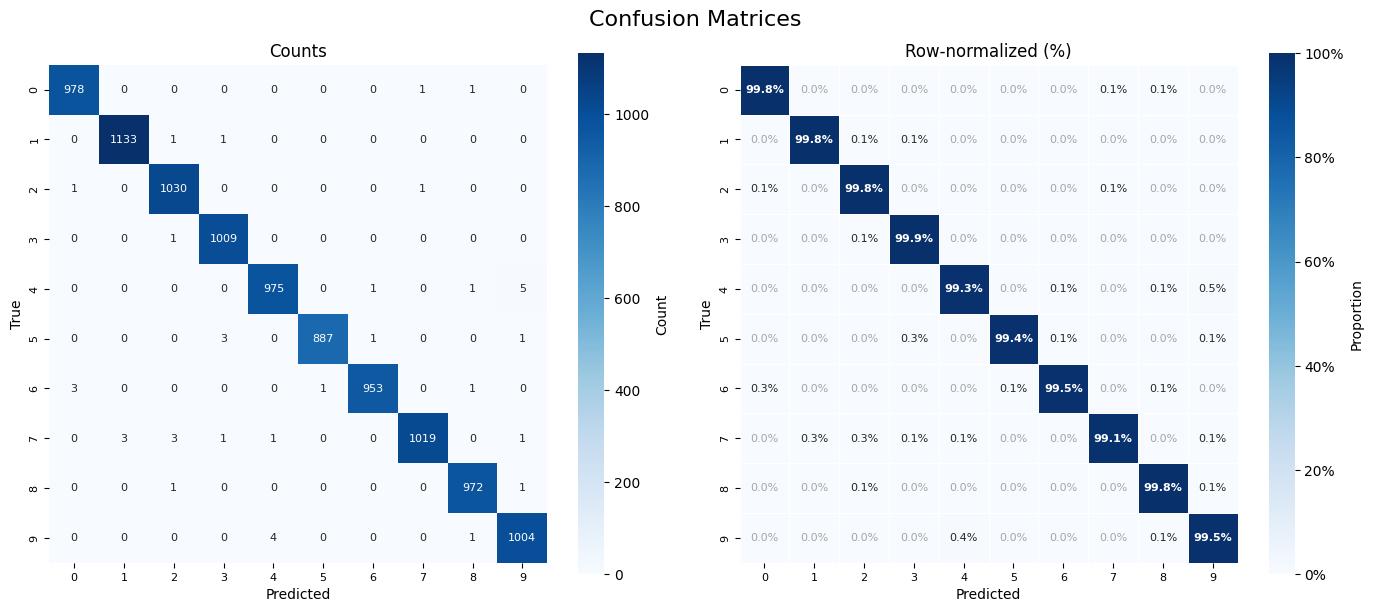

In [8]:
cm_counts = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_pct = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)), normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices", fontsize=16)

# Left chart: raw counts
ax = axes[0]
sns.heatmap(
    cm_counts, annot=True, fmt="d", cmap="Blues", cbar=True, square=True, ax=ax,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    annot_kws={"size": 8},
    cbar_kws={"label":"Count"}
)
ax.set_title("Counts", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Right chart: row-normalized percentages
ax = axes[1]
sns.heatmap(
    cm_pct, annot=True, fmt=".1%", cmap="Blues", cbar=True, square=True, ax=ax,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    vmin=0.0, vmax=1.0,
    cbar_kws={"format": PercentFormatter(1), "label": "Proportion"},
    annot_kws={"size": 8},
    linewidths=0.5, linecolor="white",
)

for (i, j), val in np.ndenumerate(cm_pct):
    txt = ax.texts[i * cm_pct.shape[1] + j]
    if i == j: txt.set_fontweight("bold")
    if val == 0.0: txt.set_alpha(0.4)

ax.set_title("Row-normalized (%)", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
# Set tick label font sizes after heatmap creation
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# Optional: quick summary of the most confused pair (off-diagonal)
mask = np.eye(cm_pct.shape[0], dtype=bool)
i, j = np.unravel_index(np.argmax(np.where(~mask, cm_pct, -1)), cm_pct.shape)

### Confusion matrices — CNN (counts & row-normalized %)
- Diagonals are **very high (≈99.1%–99.9%)** across all digits, indicating uniformly strong class separation.
- The few off-diagonal errors are **sparse and low-magnitude**. Most frequent directions (row-normalized %):
  - **9 → 4 (~0.4%)**
  - **7 → 1 (~0.3%)**
  - **6 → 0 (~0.3%)**
  - **5 → 3 (~0.3%)**
  - **4 → 9 (~0.5%)** (largest single entry, still <1%)
- These pairs match common **stroke-shape ambiguities** (loop/vertical for 9/4, serif/angle for 7/1, loop closure for 6/0).
- Takeaway: the CNN further reduces confusions vs. the MLP; remaining errors are localized and consistent with morphology.


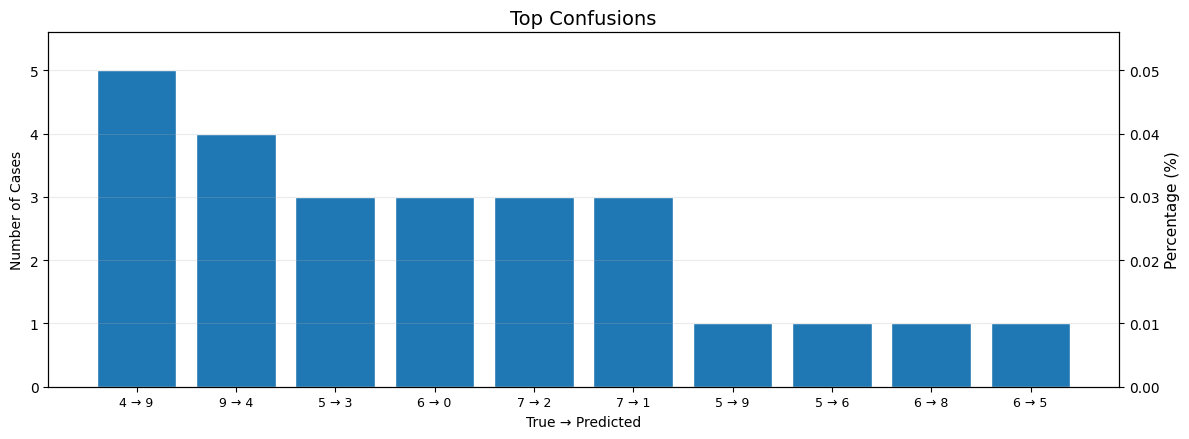

In [9]:
# ---- Build "top confusions" table from the confusion matrix ----
top_k = 10               # how many bars to show
use_percent = True       # True → rank by percentage; False → rank by raw counts

# 1) Flatten confusion matrix into pairs (i -> j), skipping the diagonal
pairs = []
n = cm_counts.shape[0]
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        count = int(cm_counts[i, j])
        pct   = float(cm_pct[i, j])  # 0..1 row-normalized
        if count > 0:
            pairs.append({
                "true": i,
                "pred": j,
                "count": count,
                "pct": pct,
                "pair": f"{CLASS_NAMES[i]} → {CLASS_NAMES[j]}",
            })

df_pairs = pd.DataFrame(pairs)

# Guard: if no off-diagonal errors exist (perfect classifier), avoid crash
if df_pairs.empty:
    print("No off-diagonal confusions found — model predictions are perfectly diagonal.")
else:
    # 2) Choose ranking metric
    if use_percent:
        df_pairs = df_pairs.sort_values("pct", ascending=False)
    else:
        df_pairs = df_pairs.sort_values("count", ascending=False)

    df_top = df_pairs.head(top_k).reset_index(drop=True)
    x_labels = df_top["pair"].tolist()

    # 3) Plot: counts (left axis) + % (right axis)
    fig_w = max(10, 1.2 * len(df_top))  # wider if many bars
    fig, ax1 = plt.subplots(figsize=(fig_w, 4.5))

    raw_counts = df_top["count"].to_numpy()
    indices = np.arange(len(raw_counts))

    bars = ax1.bar(indices, raw_counts, width=0.8, edgecolor="white")

    # Left y-axis: counts
    ax1.set_xticks(indices)
    ax1.set_xticklabels(x_labels, fontsize=9)
    ax1.set_xlabel("True → Predicted", fontsize=10)
    ax1.set_ylabel("Number of Cases", fontsize=10)
    ax1.set_title("Top Confusions", fontsize=14)
    ax1.grid(axis="y", alpha=0.25)

    # Right y-axis: percentages of total samples (not row-normalized)
    ax2 = ax1.twinx()
    total_all_data = int(cm_counts.sum())
    max_count = int(raw_counts.max()) if len(raw_counts) else 0
    margin_factor = 0.12

    # Sync y-lims with a small headroom
    ax1.set_ylim(0, max_count * (1 + margin_factor))

    # Percent scale relative to the entire dataset
    max_pct = (max_count / total_all_data) * 100 if total_all_data > 0 else 0.0
    ax2.set_ylim(0, max_pct * (1 + margin_factor))
    ax2.set_ylabel("Percentage (%)", fontsize=11)

    # Matched ticks on both axes
    ticks_count = np.linspace(0, max_count, 6, dtype=int)
    ticks_pct   = np.round((ticks_count / max(total_all_data, 1)) * 100, 2)
    ax1.set_yticks(ticks_count)
    ax2.set_yticks(ticks_pct)

    plt.subplots_adjust(bottom=0.28)
    plt.tight_layout()
    plt.show()


### Top confusions — CNN
- The bar chart ranks the **most frequent misclassifications** (true → predicted) on the test set.
- Highest entries are **4 → 9** and **9 → 4** (loop + vertical stroke similarity), followed by **5 → 3**, **6 → 0**, **7 → 2**, and **7 → 1**.
- Each bar’s height shows **raw counts** (left axis); the **right axis** gives the corresponding **share of the entire test set**, all below ~0.05%.
- Pattern indicates **localized, morphology-driven errors**. No class dominates the mistakes; residual confusions are symmetric for 4/9 and sparse for others.


In [10]:
labels = list(range(len(CLASS_NAMES)))
n_total = len(y_true)

# Per-class metrics
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, zero_division=0
)

per_class = pd.DataFrame({
    "class": CLASS_NAMES,                     
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": support.astype(int),
    "prevalence": support / max(n_total, 1),
})

# Aggregates
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="micro", zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

accuracy = float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

avg_rows = pd.DataFrame([
    {"class": "macro avg",    "precision": macro_p,    "recall": macro_r,    "f1": macro_f1,    "support": int(support.sum()), "prevalence": support.sum()/max(n_total,1)},
    {"class": "micro avg",    "precision": micro_p,    "recall": micro_r,    "f1": micro_f1,    "support": int(support.sum()), "prevalence": support.sum()/max(n_total,1)},
    {"class": "weighted avg", "precision": weighted_p, "recall": weighted_r, "f1": weighted_f1, "support": int(support.sum()), "prevalence": support.sum()/max(n_total,1)},
    {"class": "accuracy",     "precision": accuracy,   "recall": accuracy,   "f1": accuracy,    "support": int(support.sum()), "prevalence": 1.0},
])

# Display with consistent rounding
cols_order = ["class", "precision", "recall", "f1", "support", "prevalence"]
display(pd.concat([per_class, avg_rows], ignore_index=True)[cols_order]
        .assign(prevalence=lambda d: d["prevalence"].round(4))
        .round({"precision": 4, "recall": 4, "f1": 4}))


,class,precision,recall,f1,support,prevalence
0,0,0.9959,0.9980,0.9969,980,0.0980
1,1,0.9974,0.9982,0.9978,1135,0.1135
2,2,0.9942,0.9981,0.9961,1032,0.1032
3,3,0.9951,0.9990,0.9970,1010,0.1010
4,4,0.9949,0.9929,0.9939,982,0.0982
5,5,0.9989,0.9944,0.9966,892,0.0892
6,6,0.9979,0.9948,0.9963,958,0.0958
7,7,0.9980,0.9912,0.9946,1028,0.1028
8,8,0.9959,0.9979,0.9969,974,0.0974
9,9,0.9921,0.9950,0.9936,1009,0.1009


### Per-class metrics — CNN
- **Uniform performance:** macro/micro/weighted F1 all ≈ **0.9960**, indicating class balance and no single class driving accuracy.
- **Thin vs. looped digits:** simple/thin-stroke digits (e.g., **1, 0, 2, 3**) show the highest precision/recall (~0.998–0.999).  
- **Slightly harder shapes:** looped/diagonal digits (**4, 5, 7, 9**) are marginally lower but still ≥ **0.993** F1.
- **Lowest recall:** class **7** has the minimum recall (**0.9912**), consistent with confusions **7→2**/**7→1** seen in the “Top Confusions” plot.
- **Support/prevalence:** rows confirm the near-uniform test distribution (~1k per class), so metrics are directly comparable across classes.
